# Detección de Actividad Sospechosa en Video (Shoplifting)

Este notebook implementa un sistema de detección de shoplifting usando dos modelos combinados:
- **VideoMAE**: modelo de visión por computadora preentrenado para clasificación de videos
- **YOLOv8**: modelo de detección y tracking de personas en tiempo real

El experimento consta de 3 etapas:
1. Entrenamiento del modelo con datasets públicos
2. Evaluación por ventanas de tiempo
3. Detección en tiempo real con tracking por persona

## Instalación de dependencias

In [ ]:
!pip install transformers decord scikit-learn seaborn torch torchvision tqdm accelerate ultralytics lapx

---
# PARTE 1 — Entrenamiento del Modelo

Se utilizaron 2 datasets públicos de videos de shoplifting:
- **Dataset 1** (Mendeley - MNNIT Allahabad): 90 normal, 92 shoplifting
- **Dataset 2** (Kaggle): 70 normal, 86 shoplifting
- **Total combinado**: 160 normal + 178 shoplifting = **338 videos**

El modelo base es **VideoMAE** (`MCG-NJU/videomae-base`), al cual se le aplica fine-tuning con los videos del dataset. Por cada video se extraen 16 frames distribuidos uniformemente, que el modelo analiza en conjunto para determinar si la acción es Normal o Shoplifting.

El dataset se divide en:
- **70%** entrenamiento (236 videos)
- **15%** validación (51 videos)
- **15%** test (51 videos)

In [ ]:
import os
import glob
import copy
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import decord
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'model_name'   : 'MCG-NJU/videomae-base',
    'num_frames'   : 16,
    'batch_size'   : 4,
    'epochs'       : 20,
    'learning_rate': 5e-5,
    'patience'     : 5,
    'test_size'    : 0.30,
    'threshold'    : 0.5,
    'seed'         : 42,
    'output_dir'   : 'modelo_guardado',
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

### Carga y combinación de datasets

In [ ]:
normal_paths = []
normal_paths += glob.glob('dataset1/normal/*.mp4')
normal_paths += glob.glob('dataset2/normal/*.mp4')

shoplifting_paths = []
shoplifting_paths += glob.glob('dataset1/shoplifting/*.mp4')
shoplifting_paths += glob.glob('dataset2/shoplifting/*.mp4')

all_paths  = normal_paths + shoplifting_paths
all_labels = [0] * len(normal_paths) + [1] * len(shoplifting_paths)

print(f'Normal:      {len(normal_paths)} videos')
print(f'Shoplifting: {len(shoplifting_paths)} videos')
print(f'Total:       {len(all_paths)} videos')

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=CONFIG['test_size'],
    random_state=CONFIG['seed'], shuffle=True, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5,
    random_state=CONFIG['seed'], shuffle=True
)

print(f'\nSplit:')
print(f'  Train: {len(train_paths)} videos')
print(f'  Val:   {len(val_paths)} videos')
print(f'  Test:  {len(test_paths)} videos')

### Clase Dataset y DataLoaders

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, model_name='MCG-NJU/videomae-base'):
        self.video_paths = video_paths
        self.labels      = labels
        self.num_frames  = num_frames
        self.processor   = VideoMAEImageProcessor.from_pretrained(model_name)

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label      = self.labels[idx]
        try:
            vr      = decord.VideoReader(video_path)
            indices = np.linspace(0, len(vr) - 1, self.num_frames).astype(int)
            frames  = vr.get_batch(indices).asnumpy()
            inputs  = self.processor(list(frames), return_tensors='pt')
            return {
                'pixel_values': inputs['pixel_values'].squeeze(0),
                'labels'      : torch.tensor(label, dtype=torch.long)
            }
        except Exception as e:
            print(f'[ERROR] {video_path}: {e}')
            return {
                'pixel_values': torch.zeros(self.num_frames, 3, 224, 224),
                'labels'      : torch.tensor(label, dtype=torch.long)
            }

train_dataset = VideoDataset(train_paths, train_labels, CONFIG['num_frames'], CONFIG['model_name'])
val_dataset   = VideoDataset(val_paths,   val_labels,   CONFIG['num_frames'], CONFIG['model_name'])
test_dataset  = VideoDataset(test_paths,  test_labels,  CONFIG['num_frames'], CONFIG['model_name'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders creados correctamente.')

### Carga del modelo VideoMAE

In [ ]:
id2label = {0: 'Normal', 1: 'Shoplifting'}
label2id = {'Normal': 0, 'Shoplifting': 1}

model = VideoMAEForVideoClassification.from_pretrained(
    CONFIG['model_name'],
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)
model.to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo cargado. Parametros entrenables: {total_params:,}')

### Entrenamiento con Early Stopping

Se usa Early Stopping con paciencia de 5 epochs para evitar overfitting. El mejor modelo según la accuracy de validación se guarda automáticamente.

In [ ]:
optimizer        = AdamW(model.parameters(), lr=CONFIG['learning_rate'])
best_accuracy    = 0.0
best_model_state = None
patience_counter = 0
history          = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(CONFIG['epochs']):
    print(f'\nEpoch {epoch+1}/{CONFIG["epochs"]}')

    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='  Training'):
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()

    avg_train_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    print(f'  Train Loss: {avg_train_loss:.4f}')

    model.eval()
    val_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='  Validation'):
            pixel_values = batch['pixel_values'].to(device)
            labels       = batch['labels'].to(device)
            outputs      = model(pixel_values=pixel_values, labels=labels)
            probs        = F.softmax(outputs.logits, dim=-1)
            predictions  = (probs[:, 1] > CONFIG['threshold']).long()
            correct  += (predictions == labels).sum().item()
            total    += labels.size(0)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)
    print(f'  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')

    if val_accuracy > best_accuracy:
        print(f'  Mejora: {best_accuracy:.2f}% -> {val_accuracy:.2f}%')
        best_accuracy    = val_accuracy
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        os.makedirs(CONFIG['output_dir'], exist_ok=True)
        model.save_pretrained(CONFIG['output_dir'])
    else:
        patience_counter += 1
        print(f'  Sin mejora. Paciencia: {patience_counter}/{CONFIG["patience"]}')
        if patience_counter >= CONFIG['patience']:
            print('  Early stopping activado.')
            break

if best_model_state:
    model.load_state_dict(best_model_state)
print(f'\nMejor accuracy de validacion: {best_accuracy:.2f}%')

### Evaluación final y resultados

Se evalúa el mejor modelo sobre el conjunto de test (datos que nunca vio durante el entrenamiento).

In [ ]:
model.eval()
y_true = []; y_pred = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)
        outputs      = model(pixel_values=pixel_values)
        probs        = F.softmax(outputs.logits, dim=-1)
        predictions  = (probs[:, 1] > CONFIG['threshold']).long()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

print(f'Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%')
print('\nReporte de Clasificacion:')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Shoplifting']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Resultados - Shoplifting Detection', fontsize=14)

axes[0].plot(history['train_loss'], label='Train Loss', color='blue',  marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='red',   marker='x')
axes[0].set_title('Loss por Epoch'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='green', marker='s')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(True)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'], ax=axes[2])
axes[2].set_title('Confusion Matrix - Test Set')
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')

plt.tight_layout()
plt.savefig('resultados.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 2 — Predicción por Ventana de Tiempo

En lugar de analizar el video completo de una sola vez, se divide en ventanas de 5 segundos. Cada ventana se analiza de forma independiente, lo que permite identificar **en qué momento** ocurre la actividad sospechosa.

Esto es útil cuando el video tiene partes normales y partes de robo mezcladas.

In [ ]:
VIDEO_PATH_PREDICT = 'video.mp4'
WINDOW_SECONDS     = 5
THRESHOLD_PREDICT  = 0.5

In [ ]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

processor_pred = VideoMAEImageProcessor.from_pretrained('MCG-NJU/videomae-base')
model_pred     = VideoMAEForVideoClassification.from_pretrained('modelo_guardado')
model_pred.to(device)
model_pred.eval()

vr           = decord.VideoReader(VIDEO_PATH_PREDICT)
fps          = vr.get_avg_fps()
total_frames = len(vr)
duracion     = total_frames / fps
frames_por_ventana = int(fps * WINDOW_SECONDS)

print(f'Video: {VIDEO_PATH_PREDICT}')
print(f'  Duracion: {duracion:.1f}s | FPS: {fps:.1f} | Ventana: {WINDOW_SECONDS}s')
print('-' * 60)

resultados = []
inicio = 0; ventana = 0

while inicio < total_frames:
    fin = min(inicio + frames_por_ventana, total_frames)
    if (fin - inicio) < frames_por_ventana // 2:
        break

    indices      = np.linspace(inicio, fin - 1, 16).astype(int)
    frames       = vr.get_batch(indices).asnumpy()
    inputs       = processor_pred(list(frames), return_tensors='pt')
    pixel_values = inputs['pixel_values'].to(device)

    with torch.no_grad():
        outputs = model_pred(pixel_values=pixel_values)
        probs   = F.softmax(outputs.logits, dim=-1)

    prob_normal      = probs[0][0].item() * 100
    prob_shoplifting = probs[0][1].item() * 100
    prediccion       = 'SHOPLIFTING' if probs[0][1].item() > THRESHOLD_PREDICT else 'NORMAL'
    tiempo_inicio    = inicio / fps
    tiempo_fin       = fin / fps

    resultados.append({'ventana': ventana+1, 'inicio': tiempo_inicio, 'fin': tiempo_fin,
                       'prediccion': prediccion, 'prob_shoplifting': prob_shoplifting})

    alerta = '⚠️  SOSPECHOSO' if prediccion == 'SHOPLIFTING' else '✓  Normal'
    print(f'  Ventana {ventana+1:02d} | {tiempo_inicio:5.1f}s - {tiempo_fin:5.1f}s | '
          f'Normal: {prob_normal:5.1f}%  Shoplifting: {prob_shoplifting:5.1f}%  | {alerta}')

    ventana += 1; inicio += frames_por_ventana

print('-' * 60)
detecciones = [r for r in resultados if r['prediccion'] == 'SHOPLIFTING']
if detecciones:
    print(f'\n⚠️  ACTIVIDAD SOSPECHOSA DETECTADA en {len(detecciones)} ventana(s):')
    for d in detecciones:
        print(f"   → {d['inicio']:.1f}s - {d['fin']:.1f}s (confianza: {d['prob_shoplifting']:.1f}%)")
else:
    print('\n✓  Sin actividad sospechosa detectada.')

---
# PARTE 3 — Tracking por Persona + Clasificación en Tiempo Real

Esta es la versión más completa del sistema. Combina:
- **YOLOv8**: detecta y trackea a cada persona en el video con un ID único
- **VideoMAE**: analiza el comportamiento de cada persona de forma independiente

El sistema acumula 30 frames de cada persona y reclasifica cada 15 frames nuevos, permitiendo detectar el momento exacto del robo y volver a Normal si el comportamiento cambia.

El resultado se guarda como un video anotado con cajas de colores:
- 🟡 Amarillo: acumulando frames (analizando)
- 🟢 Verde: comportamiento normal
- 🔴 Rojo: actividad sospechosa detectada

In [ ]:
VIDEO_PATH_TRACK = 'video.mp4'
OUTPUT_VIDEO     = 'output.mp4'

In [ ]:
import cv2
from collections import deque
from ultralytics import YOLO

NUM_FRAMES_T    = 16
FRAMES_BUFFER   = 30
RECLASIFICAR    = 15
THRESHOLD_TRACK = 0.45

COLOR_NORMAL      = (0, 200, 0)
COLOR_SHOPLIFTING = (0, 0, 220)
COLOR_ANALIZANDO  = (200, 200, 0)

class PersonaTracker:
    def __init__(self, persona_id):
        self.id               = persona_id
        self.frames           = deque(maxlen=FRAMES_BUFFER)
        self.estado           = 'Analizando...'
        self.prob_shoplifting = 0.0
        self.frames_desde_clasificacion = 0

    def agregar_frame(self, crop):
        frame_rgb     = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame_rgb, (224, 224))
        self.frames.append(frame_resized)
        self.frames_desde_clasificacion += 1

    def listo_para_clasificar(self):
        return (len(self.frames) >= NUM_FRAMES_T and
                self.frames_desde_clasificacion >= RECLASIFICAR)

    def clasificar(self, model, processor, device):
        frames_list = list(self.frames)
        indices     = np.linspace(0, len(frames_list) - 1, NUM_FRAMES_T).astype(int)
        frames_sel  = [frames_list[i] for i in indices]
        inputs      = processor(frames_sel, return_tensors='pt')
        pixel_values = inputs['pixel_values'].to(device)
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)
            probs   = F.softmax(outputs.logits, dim=-1)
        self.prob_shoplifting = probs[0][1].item()
        self.estado = 'SHOPLIFTING' if self.prob_shoplifting > THRESHOLD_TRACK else 'Normal'
        self.frames_desde_clasificacion = 0

def dibujar_persona(frame, bbox, persona):
    x1, y1, x2, y2 = map(int, bbox)
    color  = COLOR_SHOPLIFTING if persona.estado == 'SHOPLIFTING' else \
             COLOR_NORMAL if persona.estado == 'Normal' else COLOR_ANALIZANDO
    grosor = 3 if persona.estado == 'SHOPLIFTING' else 2
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, grosor)
    label  = (f'ID{persona.id} SOSPECHOSO {persona.prob_shoplifting*100:.0f}%'
              if persona.estado == 'SHOPLIFTING' else
              f'ID{persona.id} Normal' if persona.estado == 'Normal'
              else f'ID{persona.id} Analizando...')
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 6, y1), color, -1)
    cv2.putText(frame, label, (x1 + 3, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    if persona.estado == 'SHOPLIFTING':
        cv2.putText(frame, '! ACTIVIDAD SOSPECHOSA !', (x1, y2 + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR_SHOPLIFTING, 2)

print('Clases cargadas correctamente.')

In [ ]:
yolo          = YOLO('yolov8n.pt')
processor_trk = VideoMAEImageProcessor.from_pretrained('MCG-NJU/videomae-base')
model_trk     = VideoMAEForVideoClassification.from_pretrained('modelo_guardado')
model_trk.to(device)
model_trk.eval()

cap    = cv2.VideoCapture(VIDEO_PATH_TRACK)
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f'Video: {VIDEO_PATH_TRACK} | {width}x{height} @ {fps:.1f}fps | {total} frames')

fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
out      = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))
personas = {}
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1
    if frame_idx % 30 == 0:
        print(f'  Frame {frame_idx}/{total} ({frame_idx/total*100:.1f}%)')

    results = yolo.track(frame, persist=True, classes=[0], verbose=False)
    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids   = results[0].boxes.id.cpu().numpy().astype(int)
        for bbox, pid in zip(boxes, ids):
            x1, y1, x2, y2 = max(0,int(bbox[0])), max(0,int(bbox[1])), min(width,int(bbox[2])), min(height,int(bbox[3]))
            if x2-x1 < 20 or y2-y1 < 20:
                continue
            if pid not in personas:
                personas[pid] = PersonaTracker(pid)
            personas[pid].agregar_frame(frame[y1:y2, x1:x2])
            if personas[pid].listo_para_clasificar():
                personas[pid].clasificar(model_trk, processor_trk, device)
                print(f'  Persona {pid}: {personas[pid].estado} ({personas[pid].prob_shoplifting*100:.1f}%)')
            dibujar_persona(frame, bbox, personas[pid])

    cv2.imshow('Shoplifting Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

print(f'\nVideo guardado en: {OUTPUT_VIDEO}')
print('\nRESUMEN:')
for pid, persona in personas.items():
    print(f'  Persona {pid}: {persona.estado} (shoplifting: {persona.prob_shoplifting*100:.1f}%)')

In [3]:
import glob
import numpy as np
import decord
import warnings
warnings.filterwarnings("ignore")
from torch.utils.data import Dataset, DataLoader
from transformers import VideoMAEImageProcessor
from sklearn.model_selection import train_test_split

# Rutas de videos
normal_paths = []
normal_paths += glob.glob("dataset1/normal/*.mp4")
normal_paths += glob.glob("dataset2/normal/*.mp4")
shoplifting_paths = []
shoplifting_paths += glob.glob("dataset1/shoplifting/*.mp4")
shoplifting_paths += glob.glob("dataset2/shoplifting/*.mp4")

all_paths  = normal_paths + shoplifting_paths
all_labels = [0] * len(normal_paths) + [1] * len(shoplifting_paths)

# Split igual que en entrenamiento
_, temp_paths, _, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30,
    random_state=42, shuffle=True, stratify=all_labels
)
_, test_paths, _, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5,
    random_state=42, shuffle=True
)
print(f"Test: {len(test_paths)} videos")

# Dataset y loader
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16):
        self.video_paths = video_paths
        self.labels      = labels
        self.num_frames  = num_frames
        self.processor   = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        try:
            vr      = decord.VideoReader(self.video_paths[idx])
            indices = np.linspace(0, len(vr) - 1, self.num_frames).astype(int)
            frames  = vr.get_batch(indices).asnumpy()
            inputs  = self.processor(list(frames), return_tensors="pt")
            return {
                "pixel_values": inputs["pixel_values"].squeeze(0),
                "labels"      : torch.tensor(self.labels[idx], dtype=torch.long)
            }
        except:
            return {
                "pixel_values": torch.zeros(self.num_frames, 3, 224, 224),
                "labels"      : torch.tensor(self.labels[idx], dtype=torch.long)
            }

test_loader = DataLoader(VideoDataset(test_paths, test_labels),
                         batch_size=4, shuffle=False, num_workers=0)
print("test_loader listo.")

Test: 51 videos
test_loader listo.


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 8175.63it/s]


Modelo cargado en: cuda


Evaluando: 100%|██████████| 13/13 [00:09<00:00,  1.36it/s]



Test Accuracy: 86.27%

Reporte de Clasificacion:
              precision    recall  f1-score   support

      Normal       0.77      0.95      0.85        21
 Shoplifting       0.96      0.80      0.87        30

    accuracy                           0.86        51
   macro avg       0.86      0.88      0.86        51
weighted avg       0.88      0.86      0.86        51



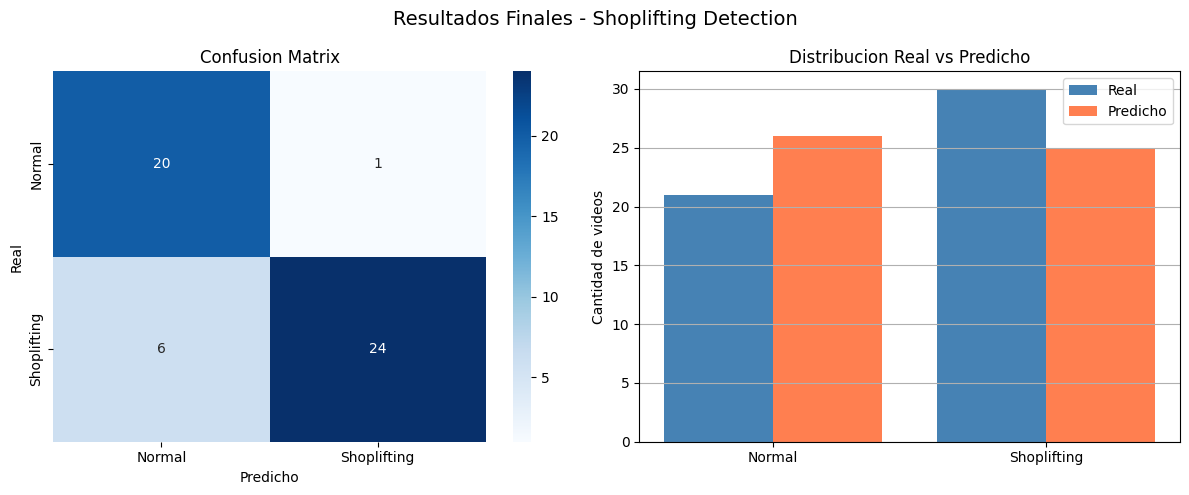

Grafica guardada como resultados_finales.png


In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cargar modelo guardado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")
model     = VideoMAEForVideoClassification.from_pretrained("modelo_guardado")
model.to(device)
model.eval()
print(f"Modelo cargado en: {device}")

# Evaluacion en test
y_true = []; y_pred = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluando"):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        outputs      = model(pixel_values=pixel_values)
        probs        = F.softmax(outputs.logits, dim=-1)
        predictions  = (probs[:, 1] > 0.5).long()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Resultados
print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print("\nReporte de Clasificacion:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Shoplifting"]))

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Resultados Finales - Shoplifting Detection", fontsize=14)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Shoplifting"],
            yticklabels=["Normal", "Shoplifting"], ax=axes[0])
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

# Distribucion de predicciones
labels_names = ["Normal", "Shoplifting"]
counts_true  = [y_true.count(0), y_true.count(1)]
counts_pred  = [y_pred.count(0), y_pred.count(1)]
x = np.arange(len(labels_names))
axes[1].bar(x - 0.2, counts_true, 0.4, label="Real",     color="steelblue")
axes[1].bar(x + 0.2, counts_pred, 0.4, label="Predicho", color="coral")
axes[1].set_title("Distribucion Real vs Predicho")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_names)
axes[1].set_ylabel("Cantidad de videos"); axes[1].legend(); axes[1].grid(axis="y")

plt.tight_layout()
plt.savefig("resultados_finales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada como resultados_finales.png")

---
## Conclusiones

- Se entrenó un modelo VideoMAE con 338 videos combinados de 2 datasets públicos
- Se obtuvo un 86.27% de accuracy en el conjunto de test
- La precision en shoplifting fue de 96%, lo que significa muy pocas falsas alarmas
- Se implementó un sistema de tracking por persona que permite identificar el momento exacto del robo
- El sistema es capaz de actualizar el estado de cada persona en tiempo real conforme cambia su comportamiento